In [2]:
from sklearn.svm import SVC, SVR, NuSVR, NuSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, brier_score_loss

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import gc

import xgboost as xgb

import statsmodels as sm
import tqdm
from sklearn.metrics import roc_auc_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings
import catboost as cb
from collections import defaultdict

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999)

# Load Data

In [3]:
# W -> women's basketball, M -> men's basketball
M_regular_results = pd.read_csv("MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv("MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv("MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv("WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv("WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv("WNCAATourneySeeds.csv")

In [4]:
# join men's and women's data into one file
regular_results = pd.concat([M_regular_results, W_regular_results])
tourney_results = pd.concat([M_tourney_results, W_tourney_results])
seeds = pd.concat([M_seeds, W_seeds])

In [5]:
season = 2003  # change if you want different cutoff year for your models
regular_results = regular_results.loc[(regular_results["Season"] >= season) & (regular_results["Season"] <= 2025)]
tourney_results = tourney_results.loc[(tourney_results["Season"] >= season) & (tourney_results["Season"] <= 2025)]
seeds = seeds.loc[(seeds["Season"] >= season) & (seeds["Season"] <= 2025)]

# Variables

### Home/Away

In [6]:
#Define Home/Away, try other possibilities
wloc = {'H':1, 'A':-1, 'N': np.nan} #{'H':1, 'A':0, 'N': 0}  # {'H':1, 'A':-1, 'N': 0} #np.nan} #-1}
#wloc = {'H':1, 'A':-1, 'N': 0} #{'H':1, 'A':0, 'N': 0}  # {'H':1, 'A':-1, 'N': 0} #np.nan} #-1}
regular_results['WHome'] = regular_results['WLoc'].map(lambda x: wloc[x])
tourney_results['WHome'] = tourney_results['WLoc'].map(lambda x: wloc[x])
# regular_results['WHome'].value_counts()
# tourney_results['WHome'].value_counts()

### Normalize Performance

In [7]:
# double the dataset with swapped team positions in box scores
def prepare_data(df):
    df = df[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT","WHome",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]]
    

    # adjustment factor for overtimes, as more stats are accumulated during overtimes
    adjot = (40 + 5 * df["NumOT"]) / 40
    adjcols = ["LScore", "WScore", 
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    for col in adjcols:
        df[col] = df[col] / adjot    
    
    dfswap = df.copy()
    df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
    dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)]
    #IMPORTANT UPDATES FOR HOMES
    df['T2_Home']=-df['T1_Home']
    dfswap['T1_Home']=-dfswap['T2_Home']
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0) * 1
    output["men_women"] = (output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))) * 1  # 0: women, 1: men
    return output

regular_data = prepare_data(regular_results)
tourney_data = prepare_data(tourney_results)

In [8]:
regular_data=regular_data[
['Season', 'DayNum', 'T1_TeamID', 'T1_Score', 'T2_TeamID', 'T2_Score', 'NumOT', 'PointDiff', 'win', 'men_women',
 'T1_FGM', 'T1_FGA', 'T1_FGM3', 'T1_FGA3', 'T1_FTM', 'T1_FTA', 'T1_OR', 'T1_DR', 'T1_Ast', 'T1_TO', 'T1_Stl', 'T1_Blk', 'T1_PF', 'T1_Home',
 'T2_FGM', 'T2_FGA', 'T2_FGM3', 'T2_FGA3', 'T2_FTM', 'T2_FTA', 'T2_OR', 'T2_DR', 'T2_Ast', 'T2_TO', 'T2_Stl', 'T2_Blk', 'T2_PF', 'T2_Home']
]

### Seeds

In [9]:
# extract seed number from `Seed` field
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))

In [10]:
seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

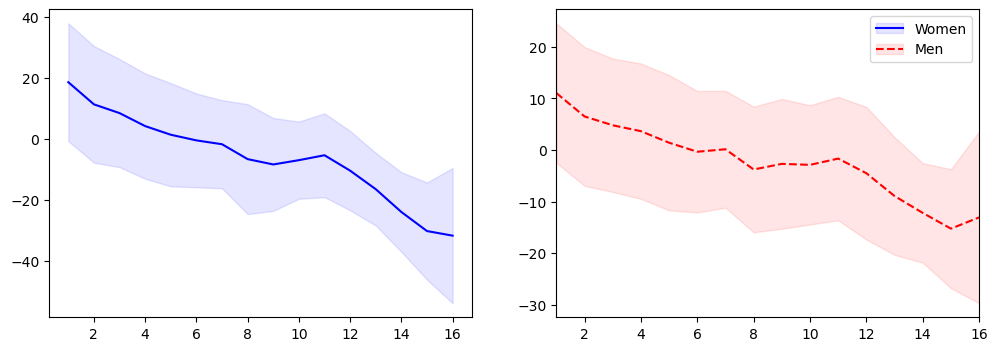

In [11]:
# let's see if __seed__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

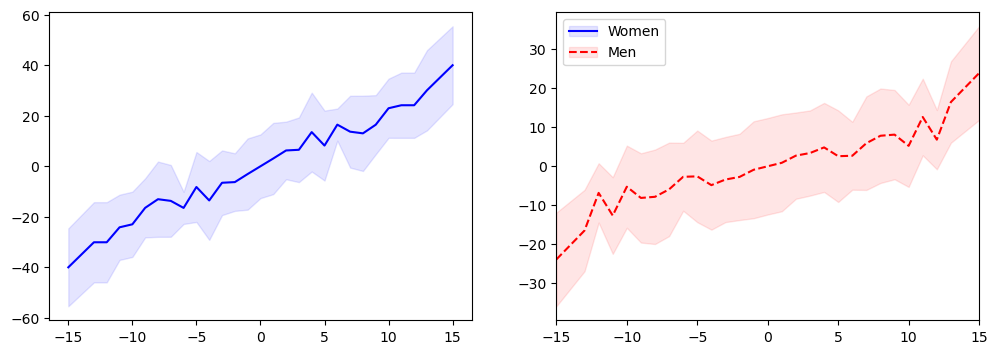

In [12]:
# let's see __seed difference__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

#### <<- Medium difficulty features ->>

### win ratio in past 14 days (only in regular)

In [13]:
#Last 14 win ratio

#Return T/F here  to  indicate if win/lose or play/not in last 14 days
regular_data['win14days'] = (regular_data['DayNum'] > 118) & (regular_data['T1_Score'] > regular_data['T2_Score'])
regular_data['win14days'] = regular_data['win14days'].map(int)
regular_data['last14days'] = (regular_data['DayNum'] > 118).map(int)

def summarize_cols(x):
    return pd.Series({
                      'WinRatio14d': x['win14days'].sum() /  (1 + x['last14days'].sum()),
                     })

In [14]:
#Show the winratio of each team in last 14 days
ss_new = regular_data.groupby(['Season','T1_TeamID']).apply(summarize_cols, include_groups=False).reset_index()
# ss_new.head()
# ss_new['WinRatio14d'].unique()

In [15]:
ss_new['season_team'] = ss_new['Season'].map(str) + '_' + ss_new['T1_TeamID'].map(str)
#create a dictionaryu for each team's win ratio in last 14 days
ratio_dict = dict(zip(ss_new['season_team'].tolist(),ss_new['WinRatio14d'].tolist()))
# ss_new.head()

In [16]:
#### use d to store match results [win times, lose times] between two teams
#### match_dict uses d to calculate winning odds (if no record, then 1)

s = regular_data['Season'].tolist()
t1 = regular_data['T1_TeamID'].tolist()
t2 = regular_data['T2_TeamID'].tolist()
s1 = regular_data['T1_Score'].tolist()
s2 = regular_data['T2_Score'].tolist()

#Record the results of two games play against each other in total number of [win,lose]
#If two teams have not play any game, assume win/lose are both 1. Prevent infinity caused by divides by 0
d = defaultdict(lambda: [1,1])
for i in range(len(s)):
    tup = str(s[i])+'_'+str(t1[i])+'_'+str(t2[i])
    if s1[i] > s2[i]:
        d[tup][0] += 1
    else:
        d[tup][1] += 1

In [17]:
#based on previous matching reuslts, calculate winning prob
match_dict = defaultdict(lambda: 0.5)
for k,v in d.items():
    match_dict[k] = v[0]/(v[0]+v[1])
#print(list(match_dict.items()))
print('done')

# print(match_dict['2003_1104_1328'])
# print(match_dict['2003_1328_1104'])

done


In [18]:
### use home_dict to store the numebr of winning games at away in each season
### Second loop may double statistics but no influence on winning prob
#### calculate away_dict using home_dict for winning prob

l1 = regular_data['T1_TeamID'].tolist()
l2 = regular_data['T2_TeamID'].tolist()
s0 = regular_data['Season'].tolist()
s1 = regular_data['T1_Score'].tolist()
s2 = regular_data['T2_Score'].tolist()
h1 = regular_data['T1_Home'].tolist()
h2 = regular_data['T2_Home'].tolist()

In [19]:
#See win/lose of each team at away
#away_stat_dict uses [0,0] is fine since the assuption here is we will have statistics for each team
away_stat_dict = defaultdict(lambda: [0,0]) #1,1])
for i in range(len(l1)):
    k = str(s0[i])+'_'+str(l1[i])
    if s1[i]>s2[i] and h1[i] == -1:
        away_stat_dict[k][0]+= 1 #s1[i] #1
    elif s1[i]<s2[i] and h1[i] == -1:
        away_stat_dict[k][1] += 1 #s2[i] #1

for i in range(len(l2)):
    k = str(s0[i])+'_'+str(l2[i])
    if s1[i]<s2[i] and h2[i] == -1:
        away_stat_dict[k][0]+= 1 # s2[i] #1
    elif s1[i]>s2[i] and h2[i] == -1 :
        away_stat_dict[k][1] += 1 #s1[i] #1

#win ratio of each team at away
#maybe should use default dict? If so what default value, 0.5?
away_dict = {}
for k,v in away_stat_dict.items():
    away_dict[k] = v[0]/(v[0]+v[1])
print('done')


done


In [20]:
#See the win/lose statistics of each team in each season [0101..] in l_dict
### Maybe highly correalted to away_win prob
#No need for second loop. Since l1 already contains all info twice.
#No influence on win rate, but win times would be doubled
#Use l_dict to calcualte awins_dict which records win prob off each team in each season

l1 = regular_data['T1_TeamID'].tolist()
l2 = regular_data['T2_TeamID'].tolist()
s0 = regular_data['Season'].tolist()
s1 = regular_data['T1_Score'].tolist()
s2 = regular_data['T2_Score'].tolist()


stat_dict = defaultdict(list)
#use range(len(l1)) same as index to loop around all rows
for i in range(len(l1)):
    k = str(s0[i])+'_'+str(l1[i])
    if s1[i]<s2[i]:
        stat_dict[k].append(0)
    else:
        stat_dict[k].append(1)
        
# for i in range(len(l2)):
#     k = str(s0[i])+'_'+str(l2[i])
#     if s1[i]>s2[i]:
#         l_dict[k].append(0)
#     else:
#         l_dict[k].append(1)

#awins_dict calcualte the win prob of each team in each season
awins_dict = defaultdict(lambda: np.nan)
for k,v in stat_dict.items():
    awins_dict[k] = np.mean(stat_dict[k])

In [21]:
#Based on win prob of each team in each season, update fluctuations of team win stats again
#Update awins_dict

#Potential problem here, data are updated using all seasons' stats, should we emphasize closer dates or same season results?
#But in that case, may not have enough data

#对手强度修正
stat_dict = defaultdict(list)
for i in range(len(l1)):
    k = str(s0[i])+'_'+str(l1[i])
    if s1[i]<s2[i]:
        #stat_dict[k].append(0) #-(1-awins_dict[str(s0[i])+'_'+str(l2[i])]))
        stat_dict[k].append(-(1-awins_dict[str(s0[i])+'_'+str(l2[i])]))
    else:
        stat_dict[k].append(awins_dict[str(s0[i])+'_'+str(l2[i])])
        
# for i in range(len(l2)):
#     k = str(s0[i])+'_'+str(l2[i])
#     if s1[i]>s2[i]:
#         l_dict[k].append(0) #-(1-awins_dict[str(s0[i])+'_'+str(l1[i])]))
#     else:
#         l_dict[k].append(awins_dict[str(s0[i])+'_'+str(l1[i])])

awins_dict = defaultdict(lambda: np.nan)
for k,v in stat_dict.items():
    awins_dict[k] = np.mean(stat_dict[k])

print('done')

done


In [22]:
# calculate averages for boxcolumns (performance) for each team in each season
#After groupby, only box colummns and season and team id, other cols disappear

#Update last 14 days win ratio
#Update 客场胜率
#Update修正完以后得胜率

#Winning odds, not yet
#Seeds difference, not yet

In [23]:
# # box score columns, for which we want features to our model
# boxcols = [
#     #"T1_Home","T2_Home",
#     "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
#     "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
#     "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
#     "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
#     "PointDiff"
# ]

In [24]:
# set(regular_data.columns.to_list())-set(boxcols)

### Defining New Rates

In [25]:
performance=[
    'T1_Score', 'T1_FGM', 'T1_FGA', 'T1_FGM3', 'T1_FGA3', 'T1_FTM', 'T1_FTA', 'T1_OR', 'T1_DR', 
    'T1_Ast', 'T1_TO', 'T1_Stl', 'T1_Blk', 'T1_PF','PointDiff', 'T2_DR', 'T2_OR'
]

In [26]:
#把需要的东西都加在放在一起，方便之后一起统计
team_data=regular_data.groupby(["Season", "T1_TeamID"]).agg(
    **{col: (col, "sum") for col in performance},
        number=("T1_Score", "size")
    ).reset_index().rename(columns={"T1_TeamID": "TeamID"})

#eFG (Effective Field Goal Percentage), 计算每个赛季每个队伍的命中率 FGR=(FGM+0.5FGM3)/FGA
team_data["eFG"] = (team_data["T1_FGM"] + 0.5*team_data["T1_FGM3"]) / team_data["T1_FGA"]

#FGR3 (3 Pointers RATE), 计算每个赛季每个队伍3分的命中率 FG3R=FGM3/FGA3
team_data["FGR3"] = team_data["T1_FGM3"] / team_data["T1_FGA3"]

#FTR (FREE THROW RATE), 计算每个赛季每个队伍罚球制造率！注意是制造，不是成功率，可以归入进攻能力 FTR=FTA/FGA
team_data["FTR"] = team_data["T1_FTA"] / team_data["T1_FGA"]

#AstR (Assists Rate), 计算助攻率 AstR=Ast/FGM
team_data["AstR"] = team_data["T1_Ast"] / team_data["T1_FGM"]

#Poss, Possession, 计算总进攻回合
team_data["Poss"] = team_data["T1_FGA"] - team_data["T1_OR"] + team_data["T1_TO"] + 0.44 * team_data["T1_FTA"]

#TOR (Turnover Rate) 失误率
team_data['TOR'] = team_data['T1_TO'] / team_data["Poss"]

#ORR 进攻回合拿到篮板概率
team_data['ORR'] = team_data['T1_OR'] / (team_data['T1_OR']+team_data['T2_DR'])

#DRR 防守回合拿到篮板概率
team_data['DRR'] = team_data['T1_DR'] / (team_data['T1_DR']+team_data['T2_OR'])

#Score_avg
team_data["Score_avg"] = team_data["T1_Score"]  / team_data["number"]

#PointDiff_avg
team_data["PointDiff_avg"] = team_data["PointDiff"]  / team_data["number"]

#Offensive Rating 平均百回合进攻效率
team_data["OffRtg"] = 100 * team_data["T1_Score"] / team_data["Poss"]

#Defensive Rating 平均百回合对手进攻效率，可以反应防守能力
team_data["DefRtg"] = 100 * (team_data["T1_Score"] - team_data["PointDiff"]) / team_data["Poss"]

In [27]:
feature_cols = [
    "eFG", "FGR3", "FTR", "AstR", "Poss", "TOR",
    "ORR", "DRR", "Score_avg", "PointDiff_avg",
    "OffRtg", "DefRtg"
]

team_features = team_data[["Season", "TeamID"] + feature_cols].copy()

team_features_T1 = team_features.rename(
    columns={col: f"T1_{col}" for col in feature_cols}
)

#先把他定义为key,之后再update
team_features_T1['T1_WinRatio14d'] = team_features_T1['Season'].map(str) + '_' + team_features_T1['TeamID'].map(str)

#away_dict 客场胜率
team_features_T1['T1_away_wins'] = team_features_T1['T1_WinRatio14d'].map(away_dict)

#基于对手强度修正的胜率
team_features_T1['T1_awins'] = team_features_T1['T1_WinRatio14d'].map(awins_dict)

#过去14天胜率 update
#ss_T1['T1_loss_delta'] = ss_T1['T1_WinRatio14d'].map(loss_delta_dict)
team_features_T1['T1_WinRatio14d'] = team_features_T1['T1_WinRatio14d'].map(ratio_dict)

tourney_data = tourney_data.merge(
    team_features_T1,
    left_on=["Season", "T1_TeamID"],
    right_on=["Season", "TeamID"],
    how="left"
).drop(columns="TeamID")

In [28]:
team_features_T2 = team_features.rename(
    columns={col: f"T2_{col}" for col in feature_cols}
)


team_features_T2['T2_WinRatio14d'] = team_features_T2['Season'].map(str) + '_' + team_features_T2['TeamID'].map(str)
team_features_T2['T2_away_wins'] = team_features_T2['T2_WinRatio14d'].map(away_dict)
team_features_T2['T2_awins'] = team_features_T2['T2_WinRatio14d'].map(awins_dict)
team_features_T2['T2_WinRatio14d'] = team_features_T2['T2_WinRatio14d'].map(ratio_dict)

tourney_data = tourney_data.merge(
    team_features_T2,
    left_on=["Season", "T2_TeamID"],
    right_on=["Season", "TeamID"],
    how="left"
).drop(columns="TeamID")

In [29]:
tourney_data['laplace_matchup'] = tourney_data['Season'].map(str)+'_'+tourney_data['T1_TeamID'].map(str)+'_'+tourney_data['T2_TeamID'].map(str)
tourney_data['laplace_matchup'] = tourney_data['laplace_matchup'].map(match_dict)

In [36]:
#大部分probs都是0.5 (not informmative)
# tourney_data['laplace_matchup'].value_counts()

#So previously, most probs are 2, 0.5, 1, 3, and 0.3. Sort of informative

# from collections import Counter
# Counter(match_dict.values())

# #Stats here are in each season
# pd.DataFrame(list(match_dict.items()), columns=["key","value"])

In [32]:
feature_cols_new=[
    "eFG", "FGR3", "FTR", "AstR", "Poss", "TOR",
    "ORR", "DRR", "Score_avg", "PointDiff_avg",
    "OffRtg", "DefRtg",
    "WinRatio14d", "away_wins", "awins"
]

In [33]:
for col in feature_cols:
    tourney_data[f"{col}_diff"] = (
        tourney_data[f"T1_{col}"] - tourney_data[f"T2_{col}"]
    )

#### <<- Hard difficulty features ->>

In [37]:
#Find best K for elo
def expected_result(elo_a, elo_b):
    return 1.0 / (1 + 10 ** ((elo_b - elo_a) / elo_width))

def update_elo(winner_elo, loser_elo,k_factor):
    expected_win = expected_result(winner_elo, loser_elo)
    change_in_elo = k_factor * (1 - expected_win)
    winner_elo += change_in_elo
    loser_elo -= change_in_elo
    return winner_elo, loser_elo


base_elo = 1000
elo_width = 400
#k_factor = 100


def elo_fill(k):
    elos = []
    for season in sorted(set(seeds["Season"])):
        ss = regular_data.loc[regular_data["Season"] == season]
        ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
        teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
        elo = dict(zip(teams, [base_elo] * len(teams)))
        for i in range(ss.shape[0]):
            w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
            w_elo, l_elo = elo[w_team], elo[l_team]
            w_elo_new, l_elo_new = update_elo(w_elo, l_elo, k)
            elo[w_team] = w_elo_new
            elo[l_team] = l_elo_new
        elo = pd.DataFrame.from_dict(elo, orient="index").reset_index()
        elo = elo.rename({"index": "TeamID", 0: "elo"}, axis=1)
        elo["Season"] = season
        elos.append(elo)
    elos = pd.concat(elos)
    return elos

In [38]:
base_elo = 1000
elo_width = 400
k_factor = 80

elos = []
for season in sorted(set(seeds["Season"])):
    ss = regular_data.loc[regular_data["Season"] == season]
    #Only focus on win==1 to calculate every match once
    ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
    teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
    elo = dict(zip(teams, [base_elo] * len(teams)))
    for i in range(ss.shape[0]):
        w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
        w_elo, l_elo = elo[w_team], elo[l_team]
        w_elo_new, l_elo_new = update_elo(w_elo, l_elo,80)
        elo[w_team] = w_elo_new
        elo[l_team] = l_elo_new
    elo = pd.DataFrame.from_dict(elo, orient="index").reset_index()
    elo = elo.rename({"index": "TeamID", 0: "elo"}, axis=1)
    elo["Season"] = season
    elos.append(elo)
elos = pd.concat(elos)

In [39]:
#Merge ELO back to tourney_data

In [40]:
elos_T1 = elos.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
elos_T2 = elos.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["elo_diff"] = tourney_data["T1_elo"] - tourney_data["T2_elo"]

In [41]:
#Make sense that team make to tourney has higher ELO

<Axes: xlabel='elo'>

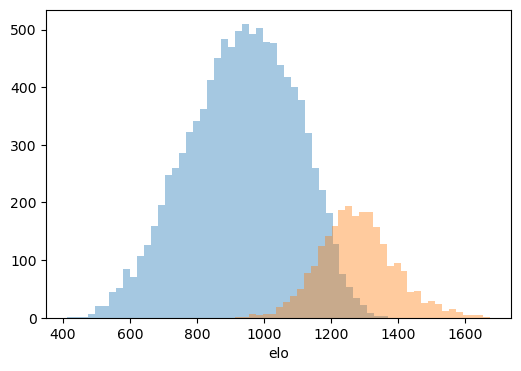

In [42]:
tmp = pd.merge(elos, tourney_data[['Season', 'T1_TeamID']].drop_duplicates(), 
               left_on = ['Season', 'TeamID'], 
               right_on = ['Season', 'T1_TeamID'],
               how = 'left')

plt.figure(figsize=(6,4))
seaborn.distplot(tmp.loc[pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)
seaborn.distplot(tmp.loc[~pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)

In [43]:
#Make sense, lower the seed, higher the ELO
#But seems only work on extreme cases: seed 1, 2, 3, 16

<Axes: xlabel='T1_seed', ylabel='T1_elo'>

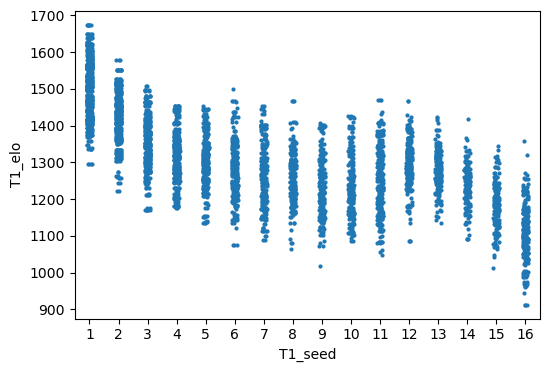

In [44]:
plt.figure(figsize=(6,4))
seaborn.stripplot(data = tourney_data, y = 'T1_elo', x = 'T1_seed', size=3)

In [45]:
# Larger seed diff, larger ELO diff, make sense
#Larger seed diff and ELO diff, more chance in winning

<Axes: xlabel='Seed_diff', ylabel='elo_diff'>

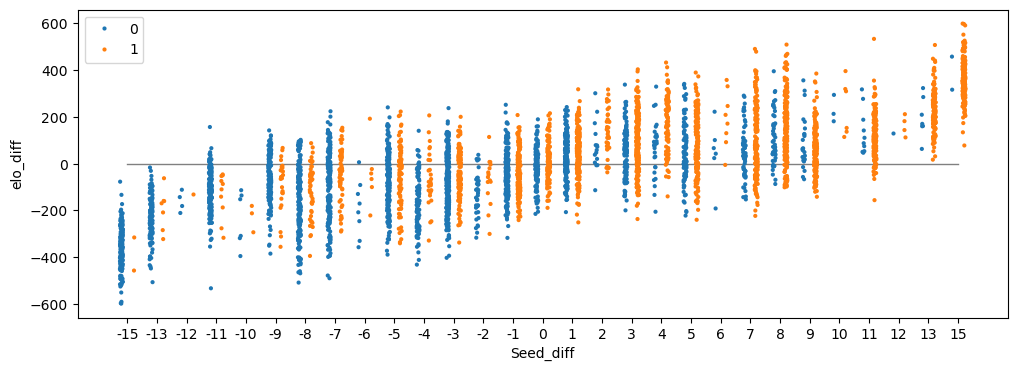

In [46]:
plt.figure(figsize=(12,4))
seaborn.stripplot(data = tourney_data, y = 'elo_diff', x = 'Seed_diff', hue='win', dodge=True, size=3)
seaborn.lineplot([0]*29,color='gray',lw = 1)

#### <<- Hardest difficulty features ->>

In [47]:
#Try to see if can use 

In [48]:
regular_data["ST1"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
regular_data["ST2"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)
seeds_T1["ST1"] = seeds_T1.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
seeds_T2["ST2"] = seeds_T2.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)

In [49]:
import statsmodels.api as sm
# collect tourney teams
st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])
# append non-tourney teams which were able to beat tourney team at least once
st = st | set(regular_data.loc[(regular_data["T1_Score"] > regular_data["T2_Score"]) & 
                               (regular_data["ST2"].isin(st)), "ST1"])

## st is the season/team_id for all teams made into tourney or beated teams went to tourney

def team_quality(season, men_women):
    # mixed effects: fixed intercept=0, random slope
    formula = "PointDiff~-1+T1_TeamID+T2_TeamID"
    glm = sm.GLM.from_formula(
        formula=formula,
        #for this season and for men/women, run the regression over dt df
        data=dt.loc[(dt["Season"] == season) & (dt["men_women"] == men_women), :],
        family=sm.families.Gaussian(),
    ).fit()
    
    quality = pd.DataFrame(glm.params).reset_index()
    quality.columns = ["TeamID", "quality"]
    quality["quality"] = quality["quality"]
    quality["Season"] = season
    quality = quality.loc[quality.TeamID.str.contains("T1_")].reset_index(drop=True)
    quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)
    return quality


glm_quality = []

#Find the rows of those match records of teams went into tourney or beated tourney teams
dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)]
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
#For those teams not went into tourney/not beat tourney teams, overwrite id into 0000
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"
seasons = sorted(set(seeds["Season"]))

#Run regression of team id to predict point diff
for s in tqdm.tqdm(seasons, unit="season"):
    if s >= 2010:  # min season for women
        glm_quality.append(team_quality(s, 0))
    if s >= 2003:  # min season for men
        glm_quality.append(team_quality(s, 1))

glm_quality = pd.concat(glm_quality).reset_index(drop=True)

glm_quality_T1 = glm_quality.copy()
glm_quality_T2 = glm_quality.copy()
glm_quality_T1.columns = ["T1_TeamID", "T1_quality", "Season"]
glm_quality_T2.columns = ["T2_TeamID", "T2_quality", "Season"]
tourney_data = pd.merge(tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["diff_quality"] = tourney_data["T1_quality"] - tourney_data["T2_quality"]

100%|██████████| 22/22 [01:43<00:00,  4.70s/season]


<Axes: ylabel='T1_quality'>

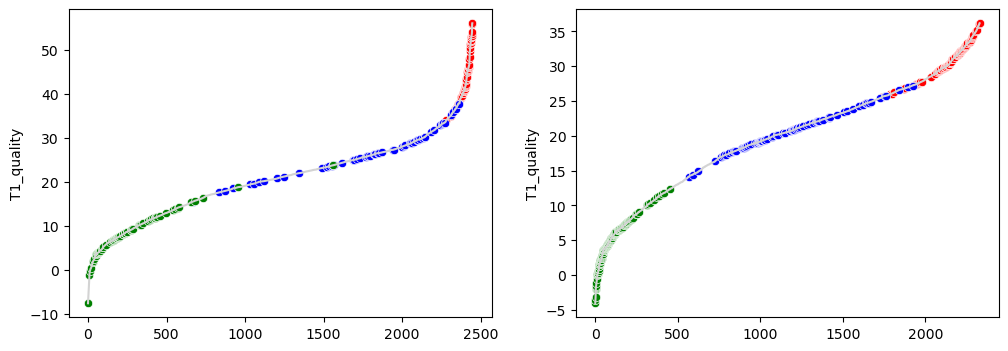

In [50]:
tmp = (
    tourney_data[["Season", "men_women", "T1_seed", "T1_quality"]]
    .drop_duplicates()
    .sort_values("T1_quality")
    .reset_index(drop=True)
)

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

seaborn.lineplot(tmp.loc[tmp["men_women"] == 0, "T1_quality"], color="lightgray", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[0])

seaborn.lineplot(tmp.loc[tmp["men_women"] == 1, "T1_quality"], color="lightgray", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[1])

In [51]:
tmp["QualitySeed"] = (
    (tmp.groupby(["Season", "men_women"])["T1_quality"].rank(ascending=False) // 4 + 1).clip(1, 16).astype(int)
)
pd.pivot_table(data=tmp, index="T1_seed", columns="QualitySeed", values="men_women", aggfunc="count").fillna(0).astype(int).style.bar(color="#5fba7d", vmin=0, vmax=50)

QualitySeed,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
T1_seed,,,,,,,,,,,,,,,,
1,81,47,12,4,1,1,1,0,1,0,0,0,0,0,0,0
2,18,52,43,21,7,5,2,0,0,0,0,0,0,0,0,0
3,6,18,36,31,26,17,6,3,0,4,1,0,0,0,0,0
4,5,15,24,26,19,23,21,9,3,2,1,0,0,0,0,0
5,0,7,15,25,22,19,23,14,8,4,8,3,0,0,0,0
6,1,3,8,15,25,31,15,19,10,10,6,4,1,0,0,0
7,0,2,3,8,19,12,21,23,23,15,12,8,2,0,0,0
8,0,0,3,7,6,17,20,23,19,24,16,6,7,0,0,0
9,0,2,0,6,10,9,12,19,27,25,20,11,5,1,1,0


In [52]:
print("Seed AUC    :", np.round(roc_auc_score(1 - tourney_data["win"], tourney_data["T1_seed"] - tourney_data["T2_seed"]), 3))
print("Quality AUC :", np.round(roc_auc_score(tourney_data["win"], tourney_data["T1_quality"] - tourney_data["T2_quality"]), 3))

Seed AUC    : 0.811
Quality AUC : 0.829


In [53]:
# who is better, experts or statistics, by season
for s in sorted(set(tourney_data['Season'])):
    st = tourney_data['Season'] == s
    print(s, 
          a:=np.round(roc_auc_score(1-tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_seed'] - tourney_data.loc[st, 'T2_seed']),3),
          b:=np.round(roc_auc_score(tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_quality'] - tourney_data.loc[st, 'T2_quality']),3),
          np.where(a>b, '', 'Q')
         )

2003 0.807 0.779 
2004 0.823 0.81 
2005 0.792 0.811 Q
2006 0.75 0.781 Q
2007 0.902 0.838 
2008 0.817 0.851 Q
2009 0.84 0.843 Q
2010 0.804 0.808 Q
2011 0.789 0.816 Q
2012 0.828 0.855 Q
2013 0.792 0.819 Q
2014 0.779 0.816 Q
2015 0.85 0.87 Q
2016 0.787 0.825 Q
2017 0.842 0.851 Q
2018 0.786 0.794 Q
2019 0.85 0.88 Q
2021 0.78 0.818 Q
2022 0.77 0.794 Q
2023 0.781 0.793 Q
2024 0.839 0.839 Q
2025 0.891 0.901 Q


# Machine-Learning Models

In [80]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# corr = tourney_data.drop(columns=['Season','T1_TeamID','T2_TeamID']).corr()

# plt.figure(figsize=(80,80))
# sns.heatmap(corr, annot=True, cmap="coolwarm")

# plt.savefig("correlation_heatmap.png", dpi=300)
# plt.show()

In [81]:
# with pd.ExcelWriter("correlation_matrix.xlsx", engine="xlsxwriter") as writer:
    
#     corr.to_excel(writer, sheet_name="Correlation")
    
#     workbook  = writer.book
#     worksheet = writer.sheets["Correlation"]
    
#     rows, cols = corr.shape

#     worksheet.conditional_format(
#     1, 1, rows, cols,
#     {
#         "type": "3_color_scale",
#         "min_color": "#3B4CC0",
#         "mid_color": "#FFFFFF",
#         "max_color": "#B40426",
#     }
# )

In [54]:
features = [
    #Dependent / Useless features
    #'Season', 'T1_TeamID', 'T2_TeamID', 'PointDiff', 'win', 
    
    'men_women',

    #T1 Features
    'T1_seed', 'T1_elo', 'T1_quality', 'T1_eFG', 'T1_FGR3', 'T1_FTR', 'T1_AstR', 'T1_Poss', 'T1_TOR', 'T1_ORR', 'T1_DRR', 
    'T1_Score_avg', 'T1_PointDiff_avg', 'T1_OffRtg', 'T1_DefRtg', 'T1_WinRatio14d', 'T1_away_wins', 'T1_awins',

    #T2 Features
    'T2_seed', 'T2_elo', 'T2_quality', 'T2_eFG', 'T2_FGR3', 'T2_FTR', 'T2_AstR', 'T2_Poss', 'T2_TOR', 'T2_ORR', 'T2_DRR', 
    'T2_Score_avg', 'T2_PointDiff_avg', 'T2_OffRtg', 'T2_DefRtg', 'T2_WinRatio14d', 'T2_away_wins', 'T2_awins',
    
    #Comparisons
    'Seed_diff', 'elo_diff', 'diff_quality', 'laplace_matchup', 'eFG_diff', 'FGR3_diff', 'FTR_diff', 'AstR_diff', 'Poss_diff', 'TOR_diff', 
    'ORR_diff', 'DRR_diff', 'Score_avg_diff', 'PointDiff_avg_diff', 'OffRtg_diff', 'DefRtg_diff']

print(f"Number of features {len(features)}")

Number of features 53


In [55]:
# Best Params 1

In [56]:
best_params = {
    "objective": "reg:squarederror",
    "booster": "gbtree",
    "tree_method": "hist",
    "grow_policy": "lossguide",
    "eval_metric": "mae",
    "verbosity": 0,
    "seed": 42,
    "num_parallel_tree": 10,
    "gamma": 10,

    "eta": 0.01,
    "max_depth": 3,
    "min_child_weight": 20,
    "subsample": 0.35,
    "colsample_bytree": 0.8
}

best_num_round = 500

In [57]:
models = {}
oof_mae = []
oof_preds = []
oof_targets = []
oof_ss = []

# leave-one-season out models
for oof_season in set(tourney_data.Season):
    x_train = tourney_data.loc[tourney_data["Season"] != oof_season, features].values
    y_train = tourney_data.loc[tourney_data["Season"] != oof_season, "PointDiff"].values
    x_val = tourney_data.loc[tourney_data["Season"] == oof_season, features].values
    y_val = tourney_data.loc[tourney_data["Season"] == oof_season, "PointDiff"].values
    s_val = tourney_data.loc[tourney_data["Season"] == oof_season, "Season"].values
    
    dtrain = xgb.DMatrix(x_train, label=y_train)
    dval = xgb.DMatrix(x_val, label=y_val)

    models[oof_season] = xgb.train(
        params=best_params,
        dtrain=dtrain,
        num_boost_round=best_num_round
    )
    
    preds = models[oof_season].predict(dval)
    tourney_data.loc[tourney_data["Season"] == oof_season, "pred_margin"] = preds
    
    print(f"oof season {oof_season} mae: {mean_absolute_error(y_val, preds)}")
    oof_mae.append(mean_absolute_error(y_val, preds))
    oof_preds += list(preds)
    oof_targets += list(y_val)
    oof_ss += list(s_val)
    
print(f"average mae: {np.mean(oof_mae)}")

oof season 2003 mae: 8.865418517837922
oof season 2004 mae: 7.972985365042566
oof season 2005 mae: 7.983535366497623
oof season 2006 mae: 8.336855338966577
oof season 2007 mae: 7.763313228120872
oof season 2008 mae: 9.58394409856717
oof season 2009 mae: 9.12781591766074
oof season 2010 mae: 8.456143966478834
oof season 2011 mae: 9.338329637899884
oof season 2012 mae: 8.1148883130274
oof season 2013 mae: 9.81098724692264
oof season 2014 mae: 10.071838361153809
oof season 2015 mae: 7.930891969207771
oof season 2016 mae: 9.971491624066193
oof season 2017 mae: 9.748285200757286
oof season 2018 mae: 10.584712429949615
oof season 2019 mae: 9.173177458962794
oof season 2021 mae: 10.546740194970322
oof season 2022 mae: 10.211536942960487
oof season 2023 mae: 9.653176960450402
oof season 2024 mae: 9.301050391506903
oof season 2025 mae: 10.032788669269154
average mae: 9.208177600012588


In [58]:
import numpy as np
import pandas as pd
from itertools import product
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

# =========================================
# Logistic grid search
# =========================================
C_grid = np.logspace(-4, 2, 13)

solvers = ["liblinear", "lbfgs", "saga"]
penalties = ["l1", "l2"]
class_weights = [None, "balanced"]

logistic_search_results = []

best_logistic_score = np.inf
best_logistic_params = None
best_logistic_oof_prob = None
best_logistic_models = None

seasons = sorted(tourney_data["Season"].unique())

for C, solver, penalty, class_weight in product(
    C_grid,
    solvers,
    penalties,
    class_weights
):
    # skip invalid combinations
    if penalty == "l1" and solver not in ["liblinear", "saga"]:
        continue

    logistic_oof_prob = np.full(len(tourney_data), np.nan)
    logistic_models = {}

    for oof_season in seasons:
        train_idx = tourney_data["Season"] != oof_season
        val_idx = tourney_data["Season"] == oof_season

        x_train = tourney_data.loc[train_idx, "pred_margin"].values.reshape(-1, 1)
        y_train = tourney_data.loc[train_idx, "win"].values

        x_val = tourney_data.loc[val_idx, "pred_margin"].values.reshape(-1, 1)

        model = LogisticRegression(
            C=C,
            solver=solver,
            penalty=penalty,
            class_weight=class_weight,
            max_iter=1000,
            random_state=0
        )

        model.fit(x_train, y_train)
        logistic_models[oof_season] = model

        prob_val = model.predict_proba(x_val)[:, 1]
        prob_val = np.clip(prob_val, 0.01, 0.99)

        logistic_oof_prob[val_idx] = prob_val

    # 用整体 OOF 概率直接算一个总 Brier
    avg_brier = brier_score_loss(tourney_data["win"], logistic_oof_prob)

    logistic_search_results.append({
        "C": C,
        "solver": solver,
        "penalty": penalty,
        "class_weight": class_weight,
        "avg_brier": avg_brier
    })

    if avg_brier < best_logistic_score:
        best_logistic_score = avg_brier
        best_logistic_params = {
            "C": C,
            "solver": solver,
            "penalty": penalty,
            "class_weight": class_weight
        }
        best_logistic_oof_prob = logistic_oof_prob.copy()
        best_logistic_models = logistic_models.copy()

logistic_results_df = (
    pd.DataFrame(logistic_search_results)
    .sort_values("avg_brier")
    .reset_index(drop=True)
)

print("Best logistic params:")
print(best_logistic_params)
print(f"Best logistic OOF Brier: {best_logistic_score:.10f}")

Best logistic params:
{'C': np.float64(0.001), 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': None}
Best logistic OOF Brier: 0.1654224086


In [61]:
def adjust_probability(p, upper_threshold, upper_delta, lower_threshold, lower_delta):

    p_new = p.copy()

    # upper adjustment
    upper_mask = p_new >= upper_threshold
    p_new[upper_mask] = p_new[upper_mask] * (1 + upper_delta)

    # lower adjustment
    lower_mask = p_new <= lower_threshold
    p_new[lower_mask] = p_new[lower_mask] * (1 - lower_delta)

    # cap
    p_new[p_new > 1] = 0.999
    p_new[p_new < 0] = 0.001

    return p_new

upper_threshold_list = [0.7, 0.75, 0.8, 0.85, 0.9]
upper_delta_list = [0.05, 0.07, 0.08, 0.10, 0.12, 0.15]

lower_threshold_list = [0.3, 0.25, 0.2, 0.15, 0.1]
lower_delta_list = [0.05, 0.07, 0.08, 0.10, 0.12, 0.15]

In [63]:
manual_search_results = []

best_manual_brier = best_logistic_score
best_manual_params = (0, 0, 0, 0)
best_manual_prob = best_logistic_oof_prob.copy()

for ut in upper_threshold_list:
    for ud in upper_delta_list:
        for lt in lower_threshold_list:
            for ld in lower_delta_list:
                prob_adj = adjust_probability(
                    p=best_logistic_oof_prob,
                    upper_threshold=ut,
                    upper_delta=ud,
                    lower_threshold=lt,
                    lower_delta=ld
                )

                brier = brier_score_loss(tourney_data["win"], prob_adj)

                manual_search_results.append({
                    "upper_threshold": ut,
                    "upper_delta": ud,
                    "lower_threshold": lt,
                    "lower_delta": ld,
                    "brier": brier
                })

                if brier < best_manual_brier:
                    best_manual_brier = brier
                    best_manual_params = (ut, ud, lt, ld)
                    best_manual_prob = prob_adj.copy()

manual_results_df = (
    pd.DataFrame(manual_search_results)
    .sort_values("brier")
    .reset_index(drop=True)
)


# =========================================
# Final selection
# =========================================
if best_manual_params == (0, 0, 0, 0):
    final_prob = best_logistic_oof_prob.copy()
    final_brier = best_logistic_score
    print("\nNo manual adjustment improves baseline.")
else:
    final_prob = best_manual_prob.copy()
    final_brier = best_manual_brier
    print("\nManual adjustment improves baseline.")


# =========================================
# Save final values
# =========================================
final_logistic_params = best_logistic_params
final_manual_params = {
    "upper_threshold": best_manual_params[0],
    "upper_delta": best_manual_params[1],
    "lower_threshold": best_manual_params[2],
    "lower_delta": best_manual_params[3]
}

print("Best logistic params:")
print(final_logistic_params)

print(f"\nLogistic baseline avg Brier: {best_logistic_score:.10f}")

print("\nBest manual adjustment params:")
print(final_manual_params)

print(f"\nFinal avg Brier: {final_brier:.10f}")


No manual adjustment improves baseline.
Best logistic params:
{'C': np.float64(0.001), 'solver': 'lbfgs', 'penalty': 'l2', 'class_weight': None}

Logistic baseline avg Brier: 0.1654224086

Best manual adjustment params:
{'upper_threshold': 0, 'upper_delta': 0, 'lower_threshold': 0, 'lower_delta': 0}

Final avg Brier: 0.1654224086


In [64]:
#Best Params 2

In [65]:
best_params = {
    "objective": "reg:squarederror",
    "booster": "gbtree",
    "tree_method": "hist",
    "grow_policy": "lossguide",
    "eval_metric": "mae",
    "verbosity": 0,
    "seed": 42,
    "num_parallel_tree": 10,
    "gamma": 10,

    "eta": 0.02,
    "max_depth": 3,
    "min_child_weight": 20,
    "subsample": 0.35,
    "colsample_bytree": 0.8
}

best_num_round = 300

In [66]:
models = {}
oof_mae = []
oof_preds = []
oof_targets = []
oof_ss = []

# leave-one-season out models
for oof_season in set(tourney_data.Season):
    x_train = tourney_data.loc[tourney_data["Season"] != oof_season, features].values
    y_train = tourney_data.loc[tourney_data["Season"] != oof_season, "PointDiff"].values
    x_val = tourney_data.loc[tourney_data["Season"] == oof_season, features].values
    y_val = tourney_data.loc[tourney_data["Season"] == oof_season, "PointDiff"].values
    s_val = tourney_data.loc[tourney_data["Season"] == oof_season, "Season"].values
    
    dtrain = xgb.DMatrix(x_train, label=y_train)
    dval = xgb.DMatrix(x_val, label=y_val)

    models[oof_season] = xgb.train(
        params=best_params,
        dtrain=dtrain,
        num_boost_round=best_num_round
    )
    
    preds = models[oof_season].predict(dval)
    tourney_data.loc[tourney_data["Season"] == oof_season, "pred_margin"] = preds
    
    print(f"oof season {oof_season} mae: {mean_absolute_error(y_val, preds)}")
    oof_mae.append(mean_absolute_error(y_val, preds))
    oof_preds += list(preds)
    oof_targets += list(y_val)
    oof_ss += list(s_val)
    
print(f"average mae: {np.mean(oof_mae)}")

oof season 2003 mae: 8.859232311500334
oof season 2004 mae: 7.969115383421174
oof season 2005 mae: 7.964135049028361
oof season 2006 mae: 8.37182262256845
oof season 2007 mae: 7.806641563367641
oof season 2008 mae: 9.536531047504266
oof season 2009 mae: 9.134497490990583
oof season 2010 mae: 8.447979996018013
oof season 2011 mae: 9.357848216902035
oof season 2012 mae: 8.114255844416398
oof season 2013 mae: 9.798857452123562
oof season 2014 mae: 10.099015537878643
oof season 2015 mae: 7.982943835290962
oof season 2016 mae: 9.927111243265482
oof season 2017 mae: 9.731031981578623
oof season 2018 mae: 10.581545930129721
oof season 2019 mae: 9.188197116447121
oof season 2021 mae: 10.579129928159853
oof season 2022 mae: 10.208938585629202
oof season 2023 mae: 9.630699094480667
oof season 2024 mae: 9.301227215093686
oof season 2025 mae: 10.060620113584378
average mae: 9.211426252699054


In [67]:
import numpy as np
import pandas as pd
from itertools import product
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss

# =========================================
# Logistic grid search
# =========================================
C_grid = np.logspace(-4, 2, 13)

solvers = ["liblinear", "lbfgs", "saga"]
penalties = ["l1", "l2"]
class_weights = [None, "balanced"]

logistic_search_results = []

best_logistic_score = np.inf
best_logistic_params = None
best_logistic_oof_prob = None
best_logistic_models = None

seasons = sorted(tourney_data["Season"].unique())

for C, solver, penalty, class_weight in product(
    C_grid,
    solvers,
    penalties,
    class_weights
):
    # skip invalid combinations
    if penalty == "l1" and solver not in ["liblinear", "saga"]:
        continue

    logistic_oof_prob = np.full(len(tourney_data), np.nan)
    logistic_models = {}

    for oof_season in seasons:
        train_idx = tourney_data["Season"] != oof_season
        val_idx = tourney_data["Season"] == oof_season

        x_train = tourney_data.loc[train_idx, "pred_margin"].values.reshape(-1, 1)
        y_train = tourney_data.loc[train_idx, "win"].values

        x_val = tourney_data.loc[val_idx, "pred_margin"].values.reshape(-1, 1)

        model = LogisticRegression(
            C=C,
            solver=solver,
            penalty=penalty,
            class_weight=class_weight,
            max_iter=1000,
            random_state=0
        )

        model.fit(x_train, y_train)
        logistic_models[oof_season] = model

        prob_val = model.predict_proba(x_val)[:, 1]
        prob_val = np.clip(prob_val, 0.01, 0.99)

        logistic_oof_prob[val_idx] = prob_val

    # 用整体 OOF 概率直接算一个总 Brier
    avg_brier = brier_score_loss(tourney_data["win"], logistic_oof_prob)

    logistic_search_results.append({
        "C": C,
        "solver": solver,
        "penalty": penalty,
        "class_weight": class_weight,
        "avg_brier": avg_brier
    })

    if avg_brier < best_logistic_score:
        best_logistic_score = avg_brier
        best_logistic_params = {
            "C": C,
            "solver": solver,
            "penalty": penalty,
            "class_weight": class_weight
        }
        best_logistic_oof_prob = logistic_oof_prob.copy()
        best_logistic_models = logistic_models.copy()

logistic_results_df = (
    pd.DataFrame(logistic_search_results)
    .sort_values("avg_brier")
    .reset_index(drop=True)
)

print("Best logistic params:")
print(best_logistic_params)
print(f"Best logistic OOF Brier: {best_logistic_score:.10f}")

Best logistic params:
{'C': np.float64(0.001), 'solver': 'saga', 'penalty': 'l2', 'class_weight': None}
Best logistic OOF Brier: 0.1654454087


In [68]:
manual_search_results = []

best_manual_brier = best_logistic_score
best_manual_params = (0, 0, 0, 0)
best_manual_prob = best_logistic_oof_prob.copy()

for ut in upper_threshold_list:
    for ud in upper_delta_list:
        for lt in lower_threshold_list:
            for ld in lower_delta_list:
                prob_adj = adjust_probability(
                    p=best_logistic_oof_prob,
                    upper_threshold=ut,
                    upper_delta=ud,
                    lower_threshold=lt,
                    lower_delta=ld
                )

                brier = brier_score_loss(tourney_data["win"], prob_adj)

                manual_search_results.append({
                    "upper_threshold": ut,
                    "upper_delta": ud,
                    "lower_threshold": lt,
                    "lower_delta": ld,
                    "brier": brier
                })

                if brier < best_manual_brier:
                    best_manual_brier = brier
                    best_manual_params = (ut, ud, lt, ld)
                    best_manual_prob = prob_adj.copy()

manual_results_df = (
    pd.DataFrame(manual_search_results)
    .sort_values("brier")
    .reset_index(drop=True)
)


# =========================================
# Final selection
# =========================================
if best_manual_params == (0, 0, 0, 0):
    final_prob = best_logistic_oof_prob.copy()
    final_brier = best_logistic_score
    print("\nNo manual adjustment improves baseline.")
else:
    final_prob = best_manual_prob.copy()
    final_brier = best_manual_brier
    print("\nManual adjustment improves baseline.")


# =========================================
# Save final values
# =========================================
final_logistic_params = best_logistic_params
final_manual_params = {
    "upper_threshold": best_manual_params[0],
    "upper_delta": best_manual_params[1],
    "lower_threshold": best_manual_params[2],
    "lower_delta": best_manual_params[3]
}

print("Best logistic params:")
print(final_logistic_params)

print(f"\nLogistic baseline avg Brier: {best_logistic_score:.10f}")

print("\nBest manual adjustment params:")
print(final_manual_params)

print(f"\nFinal avg Brier: {final_brier:.10f}")


No manual adjustment improves baseline.
Best logistic params:
{'C': np.float64(0.001), 'solver': 'saga', 'penalty': 'l2', 'class_weight': None}

Logistic baseline avg Brier: 0.1654454087

Best manual adjustment params:
{'upper_threshold': 0, 'upper_delta': 0, 'lower_threshold': 0, 'lower_delta': 0}

Final avg Brier: 0.1654454087
